# Redes neuronales

Vamos a hacer un modelo que aprende la función lógica XOR, un ejemplo clásico para entender cómo aprenden las redes neuronales.

Problema: XOR

Queremos que la red aprenda la siguiente tabla:


x1 | x2 | y
---|----|---
0  | 0  | 0
0  | 1  | 1
1  | 0  | 1
1  | 1  | 0


In [6]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# Datos de entrada (XOR)
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])

# Definición del modelo
model = keras.Sequential([
    keras.layers.Dense(2, input_dim=2, activation='relu'),  # Capa oculta
    keras.layers.Dense(1, activation='sigmoid')             # Capa de salida
])

# Compilación del modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenamiento
model.fit(X, y, epochs=500, verbose=0)

# Evaluación
predicciones = model.predict(X)
print("Predicciones:")
print(np.round(predicciones))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicciones:
[[0.]
 [0.]
 [1.]
 [1.]]


Qué hace cada parte:

- Dense(2, input_dim=2, activation='relu') → crea una capa oculta con 2 neuronas.

- Dense(1, activation='sigmoid') → capa de salida con 1 neurona que da un valor entre 0 y 1.

- loss='binary_crossentropy' → función de error para clasificación binaria.

- optimizer='adam' → algoritmo que ajusta los pesos automáticamente.

- epochs=500 → número de veces que el modelo verá todos los datos para aprender.

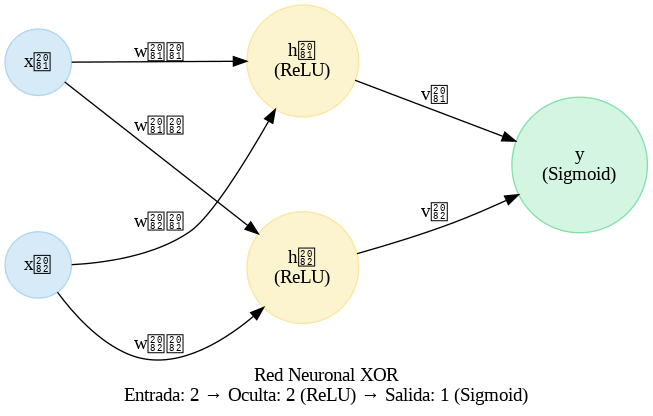

In [7]:
!apt-get -qq install graphviz
!pip install graphviz

from graphviz import Digraph
from IPython.display import Image

# Crear el grafo
dot = Digraph('XOR_NN', format='png')
dot.attr(rankdir='LR', splines='spline', nodesep='1.0', ranksep='1.2')

# --- Nodos de entrada ---
dot.attr('node', shape='circle', style='filled', color='#AED6F1', fillcolor='#D6EAF8')
dot.node('x1', 'x₁')
dot.node('x2', 'x₂')

# --- Neuronas capa oculta ---
dot.attr('node', shape='circle', style='filled', color='#F9E79F', fillcolor='#FCF3CF')
dot.node('h1', 'h₁\n(ReLU)')
dot.node('h2', 'h₂\n(ReLU)')

# --- Neurona de salida ---
dot.attr('node', shape='circle', style='filled', color='#82E0AA', fillcolor='#D5F5E3')
dot.node('y', 'y\n(Sigmoid)')

# --- Conexiones entrada → capa oculta ---
dot.edge('x1', 'h1', label=' w₁₁ ')
dot.edge('x1', 'h2', label=' w₁₂ ')
dot.edge('x2', 'h1', label=' w₂₁ ')
dot.edge('x2', 'h2', label=' w₂₂ ')

# --- Conexiones capa oculta → salida ---
dot.edge('h1', 'y', label=' v₁ ')
dot.edge('h2', 'y', label=' v₂ ')

# --- Etiquetas decorativas ---
dot.attr(label=r"Red Neuronal XOR\nEntrada: 2 → Oculta: 2 (ReLU) → Salida: 1 (Sigmoid)", fontsize='14')

# Renderizar y mostrar
dot.render('xor_model_diagram', cleanup=True)
Image(filename='xor_model_diagram.png')

# Evolución del error

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


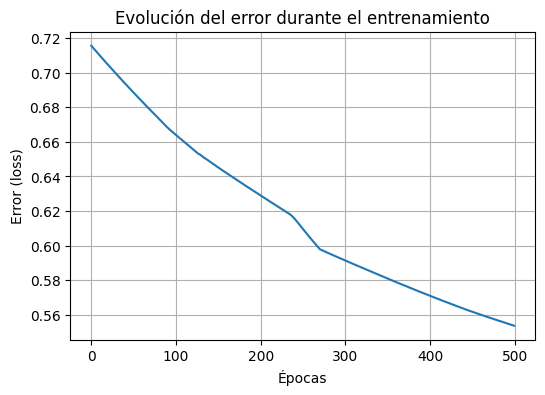

In [8]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Datos de entrada (XOR)
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])

# Definir modelo
model = keras.Sequential([
    keras.layers.Dense(4, input_dim=2, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

# Compilar modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar modelo
history = model.fit(X, y, epochs=500, verbose=0)

# --- Visualización 1: evolución del error ---
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'])
plt.title('Evolución del error durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Error (loss)')
plt.grid(True)
plt.show()



# Visualización de la frontera de error

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


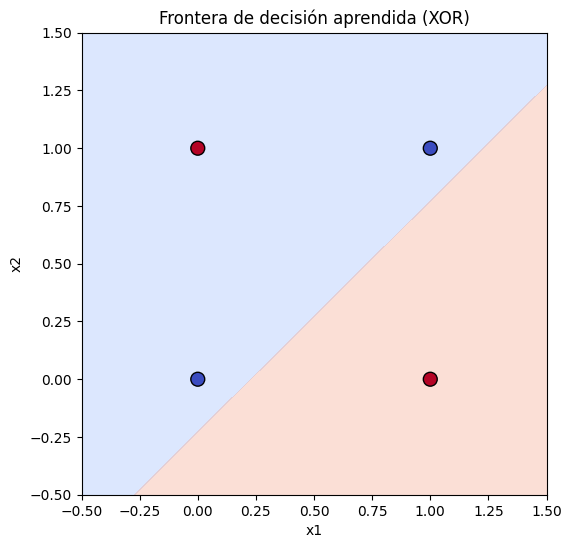

In [9]:
x1 = np.linspace(-0.5, 1.5, 100)
x2 = np.linspace(-0.5, 1.5, 100)
xx1, xx2 = np.meshgrid(x1, x2)
X_grid = np.c_[xx1.ravel(), xx2.ravel()]

# Predecir para toda la malla
y_pred_grid = model.predict(X_grid)
y_pred_grid = y_pred_grid.reshape(xx1.shape)

# Dibujar frontera de decisión
plt.figure(figsize=(6,6))
plt.contourf(xx1, xx2, y_pred_grid, levels=[0,0.5,1], alpha=0.3, cmap='coolwarm')
plt.scatter(X[:,0], X[:,1], c=y.ravel(), cmap='coolwarm', edgecolors='k', s=100)
plt.title('Frontera de decisión aprendida (XOR)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()